/home/jsl/anaconda3/envs/SCA/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/jsl/anaconda3/envs/SCA/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/jsl/anaconda3/envs/SCA/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 12152 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/jsl/anaconda3/envs/SCA/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See h

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

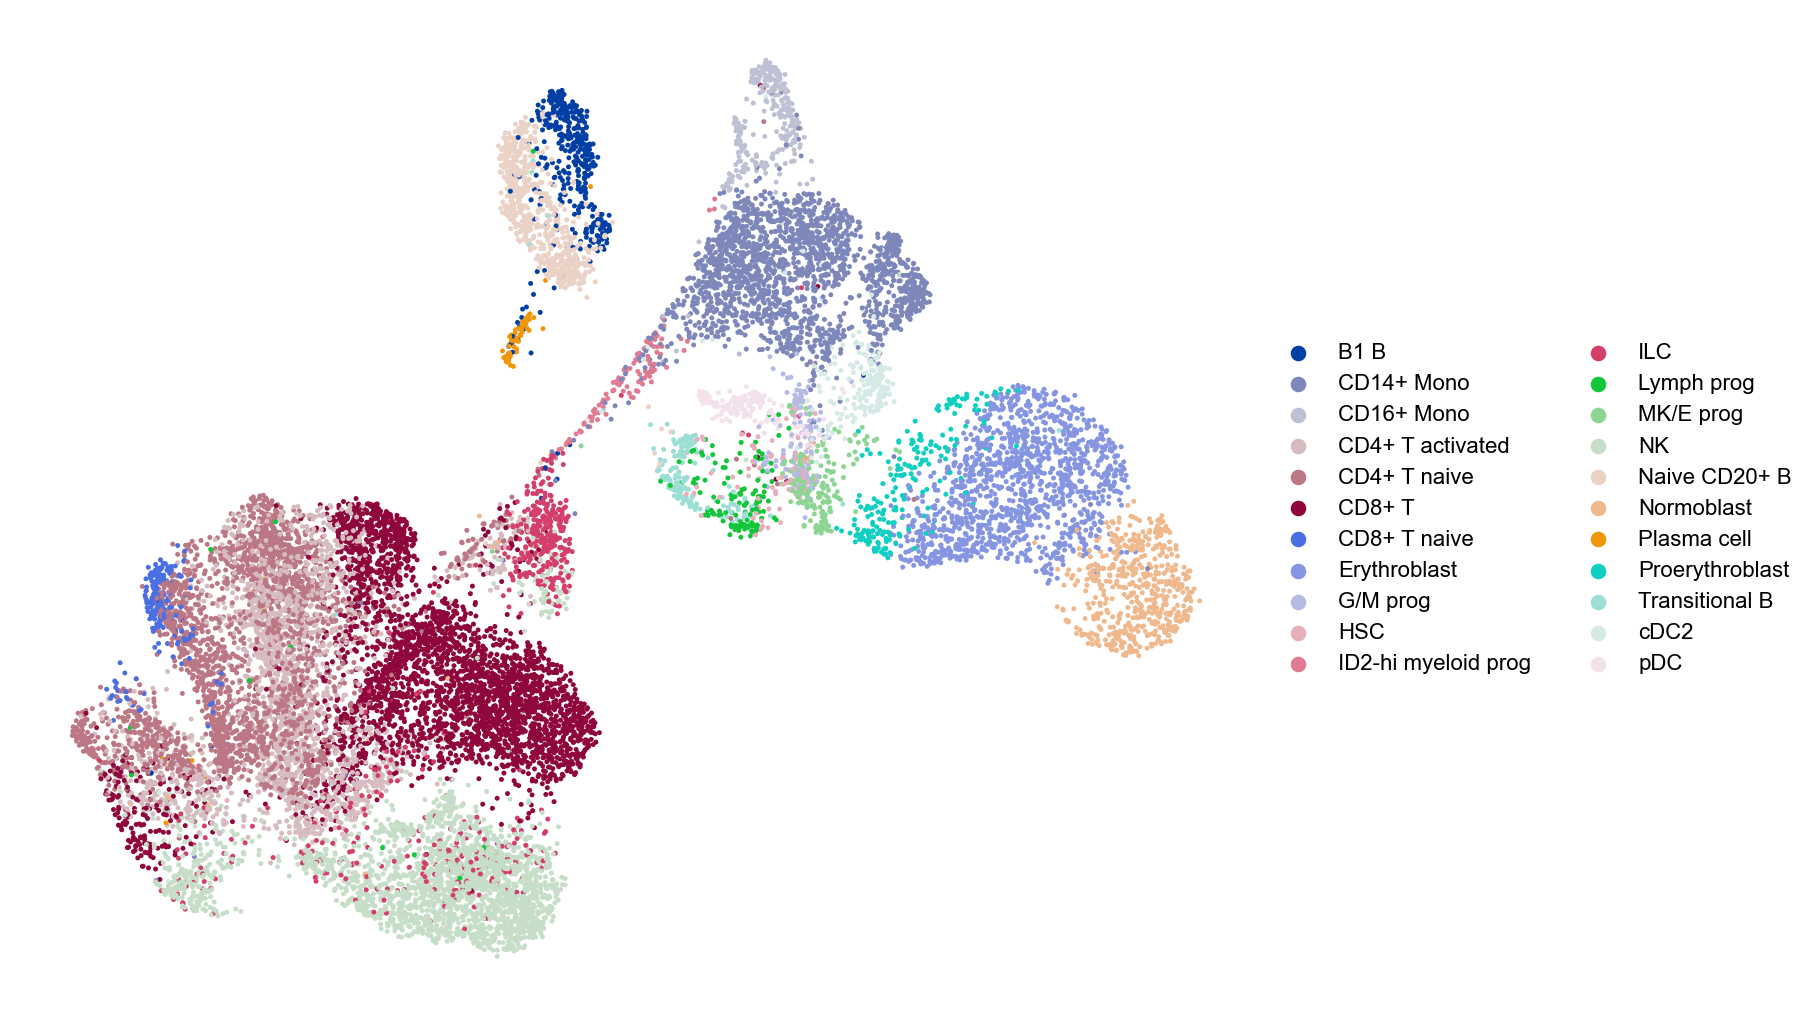

In [4]:
import os
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt


sc.set_figure_params(scanpy = False)
plt.rcParams["font.family"] = "Arial"
workdir = "./ComicGTN_reproducibility/Data/BMMC-bench-1"
RNA_seq = sc.read(os.path.join(workdir, "Gene_Cell.mtx"))
Cell_names = pd.read_csv(os.path.join(workdir, "Cell_names.tsv"), sep = "\t", header = None)
Cell_types = pd.read_csv(os.path.join(workdir, "Cell_types.tsv"), sep = "\t", header = None)
Gene_names = pd.read_csv(os.path.join(workdir, "Gene_names.tsv"), sep = "\t", header = None)
RNA_count = RNA_seq.X


adata =  ad.AnnData(RNA_count.transpose(), dtype = "int32")
adata.obs_names = Cell_names[0]
adata.var_names = Gene_names[0]
adata.var_names_make_unique()
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.obs["cell_types"] = Cell_types[0].tolist()
adata.obs["cell_types"] = adata.obs["cell_types"].astype("category")
sc.pp.neighbors(adata)
sc.tl.umap(adata)


fig, ax = plt.subplots(figsize = (10, 8))
sc.pl.umap(adata, size = 20, color = ["cell_types"], title = "", frameon = False, ax = ax, show = False)

In [1]:
from shannonca.dimred import reduce_scanpy


sc.set_figure_params(scanpy = False)
plt.rcParams["font.family"] = "Arial"
RNA_seq = sc.read(os.path.join(workdir, "Gene_Cell.mtx"))
Cell_names = pd.read_csv(os.path.join(workdir, "Cell_names.tsv"), sep = "\t", header = None)
Gene_names = pd.read_csv(os.path.join(workdir, "Gene_names.tsv"), sep = "\t", header = None)
RNA_count = RNA_seq.X
adata =  ad.AnnData(RNA_count.transpose(), dtype = "int32")
adata.obs_names = Cell_names[0]
adata.var_names = Gene_names[0]
adata.var_names_make_unique()
reduce_scanpy(adata, n_comps = 50, iters = 5, keep_scores = True, keep_loadings = True)

/home/jsl/anaconda3/envs/SCA/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


iteration 1
iteration 2
iteration 3
iteration 4
iteration 5


In [5]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
sc.pp.neighbors(adata, use_rep = "X_sca")
sc.tl.leiden(adata, resolution = 0.8)
sc.tl.umap(adata)

adata.obs["leiden"].to_csv(os.path.join(workdir, "SCA_pred.tsv"), sep="\t", header=False, index=False)